In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
movies = pd.read_csv(
    "../data/movies_metadata.csv",
    low_memory=False
)

movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [3]:
movies.shape

(45466, 24)

In [4]:
movies.columns.tolist()

['adult',
 'belongs_to_collection',
 'budget',
 'genres',
 'homepage',
 'id',
 'imdb_id',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'poster_path',
 'production_companies',
 'production_countries',
 'release_date',
 'revenue',
 'runtime',
 'spoken_languages',
 'status',
 'tagline',
 'title',
 'video',
 'vote_average',
 'vote_count']

In [5]:
movies.columns.tolist()

['adult',
 'belongs_to_collection',
 'budget',
 'genres',
 'homepage',
 'id',
 'imdb_id',
 'original_language',
 'original_title',
 'overview',
 'popularity',
 'poster_path',
 'production_companies',
 'production_countries',
 'release_date',
 'revenue',
 'runtime',
 'spoken_languages',
 'status',
 'tagline',
 'title',
 'video',
 'vote_average',
 'vote_count']

In [6]:
movies[[
    "title",
    "budget",
    "revenue",
    "runtime",
    "vote_average",
    "vote_count",
    "genres",
    "release_date"
]].head(10)

,title,budget,revenue,runtime,vote_average,vote_count,genres,release_date
0,Toy Story,30000000,373554033.0,81.0,7.7,5415.0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",1995-10-30
1,Jumanji,65000000,262797249.0,104.0,6.9,2413.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",1995-12-15
2,Grumpier Old Men,0,0.0,101.0,6.5,92.0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",1995-12-22
3,Waiting to Exhale,16000000,81452156.0,127.0,6.1,34.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",1995-12-22
4,Father of the Bride Part II,0,76578911.0,106.0,5.7,173.0,"[{'id': 35, 'name': 'Comedy'}]",1995-02-10
5,Heat,60000000,187436818.0,170.0,7.7,1886.0,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",1995-12-15
6,Sabrina,58000000,0.0,127.0,6.2,141.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",1995-12-15
7,Tom and Huck,0,0.0,97.0,5.4,45.0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",1995-12-22
8,Sudden Death,35000000,64350171.0,106.0,5.5,174.0,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",1995-12-22
9,GoldenEye,58000000,352194034.0,130.0,6.6,1194.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",1995-11-16


In [8]:
financial = movies[
    (movies["budget"] > 0) &
    (movies["revenue"] > 0)
].copy()

print("Movies remaining:", len(financial))

Movies remaining: 5381


In [7]:
movies["budget"] = pd.to_numeric(movies["budget"], errors="coerce")
movies["revenue"] = pd.to_numeric(movies["revenue"], errors="coerce")

# Check how many movies have usable financial data
print("Total movies:", len(movies))
print("Movies with budget > 0:", (movies["budget"] > 0).sum())
print("Movies with revenue > 0:", (movies["revenue"] > 0).sum())
print(
    "Movies with both budget and revenue > 0:",
    ((movies["budget"] > 0) & (movies["revenue"] > 0)).sum()
)

Total movies: 45466
Movies with budget > 0: 8890
Movies with revenue > 0: 7408
Movies with both budget and revenue > 0: 5381


In [9]:
financial["profitable"] = (
    financial["revenue"] > financial["budget"]
).astype(int)

financial["profit"] = (
    financial["revenue"] - financial["budget"]
)

financial["roi"] = (
    financial["revenue"] - financial["budget"]
) / financial["budget"]

In [10]:
financial[[
    "title",
    "budget",
    "revenue",
    "profit",
    "roi",
    "profitable"
]].head(10)

,title,budget,revenue,profit,roi,profitable
0,Toy Story,30000000.0,373554033.0,343554033.0,11.451801,1
1,Jumanji,65000000.0,262797249.0,197797249.0,3.043035,1
3,Waiting to Exhale,16000000.0,81452156.0,65452156.0,4.090760,1
5,Heat,60000000.0,187436818.0,127436818.0,2.123947,1
8,Sudden Death,35000000.0,64350171.0,29350171.0,0.838576,1
9,GoldenEye,58000000.0,352194034.0,294194034.0,5.072311,1
10,The American President,62000000.0,107879496.0,45879496.0,0.739992,1
13,Nixon,44000000.0,13681765.0,-30318235.0,-0.689051,0
14,Cutthroat Island,98000000.0,10017322.0,-87982678.0,-0.897782,0
15,Casino,52000000.0,116112375.0,64112375.0,1.232930,1


In [11]:
financial["profitable"].value_counts()

profitable
1    3756
0    1625
Name: count, dtype: int64

In [12]:
financial["profitable"].value_counts(normalize=True)

profitable
1    0.698012
0    0.301988
Name: proportion, dtype: float64

In [13]:
financial[[
    "budget",
    "revenue",
    "profit",
    "roi",
    "runtime",
    "vote_average"
]].describe()

,budget,revenue,profit,roi,runtime,vote_average
count,5.381000e+03,5.381000e+03,5.381000e+03,5.381000e+03,5380.000000,5381.000000
mean,3.109480e+07,9.031812e+07,5.922333e+07,5.564899e+03,109.827695,6.272849
std,4.016263e+07,1.661423e+08,1.395368e+08,2.168566e+05,22.041188,0.927983
min,1.000000e+00,1.000000e+00,-1.657101e+08,-9.999995e-01,0.000000,0.000000
25%,5.037000e+06,7.011317e+06,-1.468000e+06,-2.129557e-01,95.000000,5.700000
50%,1.700000e+07,2.991874e+07,1.108426e+07,1.056683e+00,106.000000,6.300000
75%,4.000000e+07,9.996575e+07,6.212776e+07,3.244444e+00,120.000000,6.900000
max,3.800000e+08,2.787965e+09,2.550965e+09,1.239638e+07,338.000000,9.100000


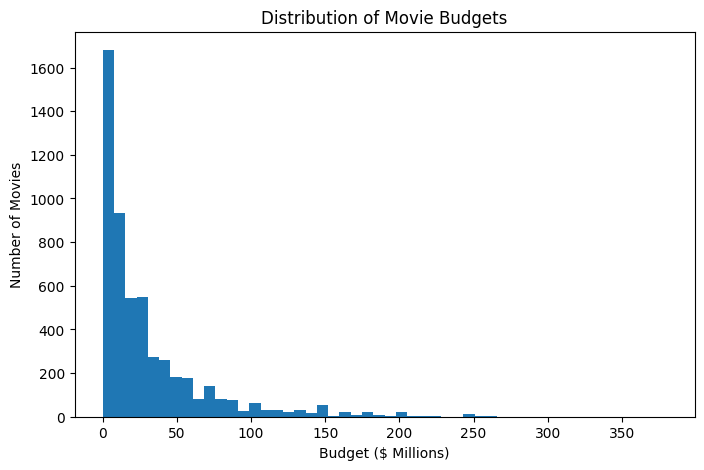

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(financial["budget"] / 1_000_000, bins=50)

plt.xlabel("Budget ($ Millions)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Budgets")

plt.show()

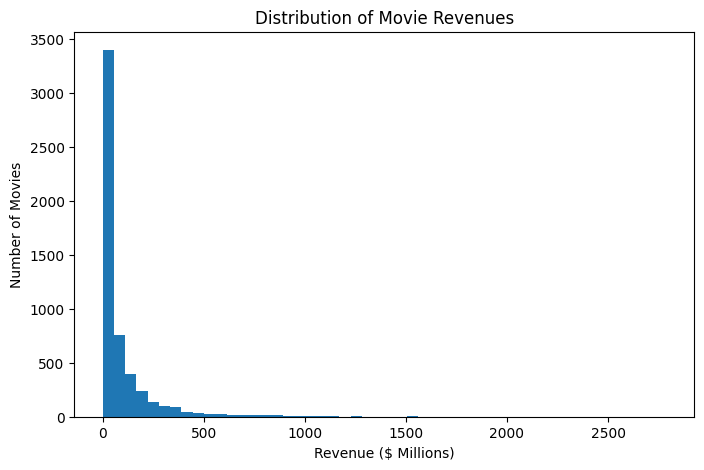

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(financial["revenue"] / 1_000_000, bins=50)

plt.xlabel("Revenue ($ Millions)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Revenues")

plt.show()

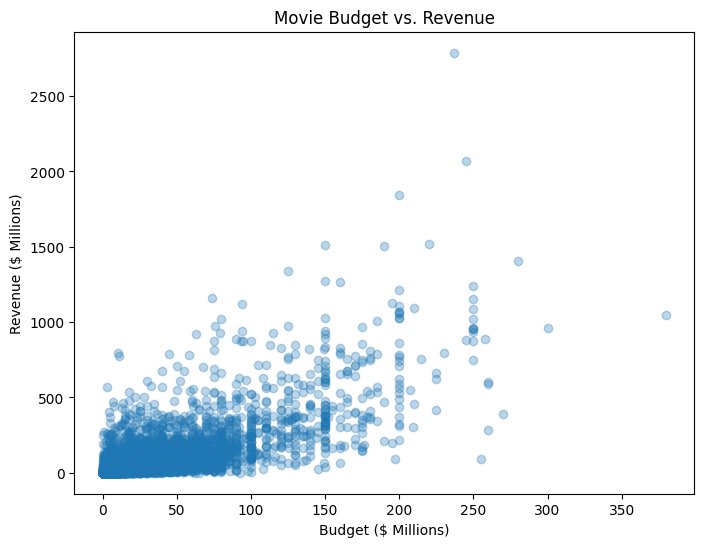

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    financial["budget"] / 1_000_000,
    financial["revenue"] / 1_000_000,
    alpha=0.3
)

plt.xlabel("Budget ($ Millions)")
plt.ylabel("Revenue ($ Millions)")
plt.title("Movie Budget vs. Revenue")

plt.show()

In [17]:
financial[["budget", "revenue"]].corr()

,budget,revenue
budget,1.000000,0.730271
revenue,0.730271,1.000000


In [18]:
financial["budget_category"] = pd.cut(
    financial["budget"],
    bins=[0, 10_000_000, 30_000_000, 75_000_000, 150_000_000, float("inf")],
    labels=[
        "Under $10M",
        "$10–30M",
        "$30–75M",
        "$75–150M",
        "$150M+"
    ]
)

budget_analysis = financial.groupby(
    "budget_category",
    observed=False
).agg(
    movies=("profitable", "count"),
    profitability_rate=("profitable", "mean"),
    median_roi=("roi", "median"),
    median_revenue=("revenue", "median")
)

budget_analysis

,movies,profitability_rate,median_roi,median_revenue
budget_category,,,,
Under $10M,2034,0.686824,1.376203,6703184.0
$10–30M,1671,0.643327,0.674131,31672907.0
$30–75M,1111,0.713771,0.872862,90683916.0
$75–150M,442,0.846154,1.314915,245575498.5
$150M+,123,0.951220,1.991451,604942143.0


In [19]:
financial[["budget", "vote_average"]].corr()

,budget,vote_average
budget,1.000000,-0.005641
vote_average,-0.005641,1.000000


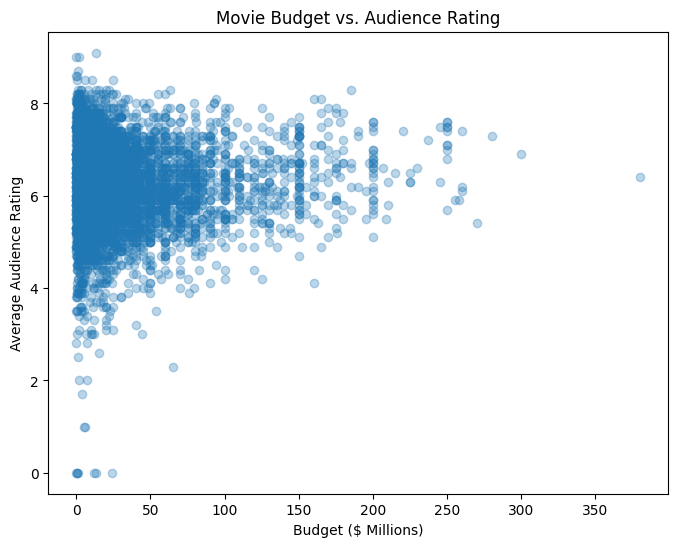

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    financial["budget"] / 1_000_000,
    financial["vote_average"],
    alpha=0.3
)

plt.xlabel("Budget ($ Millions)")
plt.ylabel("Average Audience Rating")
plt.title("Movie Budget vs. Audience Rating")

plt.show()

In [21]:
import ast

financial["genre_list"] = financial["genres"].apply(
    lambda x: [genre["name"] for genre in ast.literal_eval(x)]
)

In [22]:
financial[["title", "genre_list"]].head(10)

,title,genre_list
0,Toy Story,"[Animation, Comedy, Family]"
1,Jumanji,"[Adventure, Fantasy, Family]"
3,Waiting to Exhale,"[Comedy, Drama, Romance]"
5,Heat,"[Action, Crime, Drama, Thriller]"
8,Sudden Death,"[Action, Adventure, Thriller]"
9,GoldenEye,"[Adventure, Action, Thriller]"
10,The American President,"[Comedy, Drama, Romance]"
13,Nixon,"[History, Drama]"
14,Cutthroat Island,"[Action, Adventure]"
15,Casino,"[Drama, Crime]"


In [23]:
genre_df = financial.explode("genre_list")

In [24]:
genre_analysis = genre_df.groupby("genre_list").agg(
    movies=("title", "count"),
    profitability_rate=("profitable", "mean"),
    median_roi=("roi", "median"),
    median_revenue=("revenue", "median"),
    average_rating=("vote_average", "mean")
)

genre_analysis = genre_analysis[
    genre_analysis["movies"] >= 100
].sort_values("profitability_rate", ascending=False)

genre_analysis

,movies,profitability_rate,median_roi,median_revenue,average_rating
genre_list,,,,,
Family,532,0.789474,1.483950,94547600.5,6.187406
Animation,293,0.778157,1.774916,117932401.0,6.477474
Adventure,960,0.759375,1.291962,85370015.0,6.249687
Fantasy,511,0.751468,1.126080,84552250.0,6.170841
Horror,586,0.728669,1.484928,24023266.5,5.825085
Science Fiction,635,0.719685,1.002247,50244700.0,6.102205
Action,1415,0.716608,1.014444,54700105.0,6.104311
Comedy,1852,0.714903,1.106664,32307307.0,6.089525
War,204,0.710784,1.028807,25561499.5,6.714216


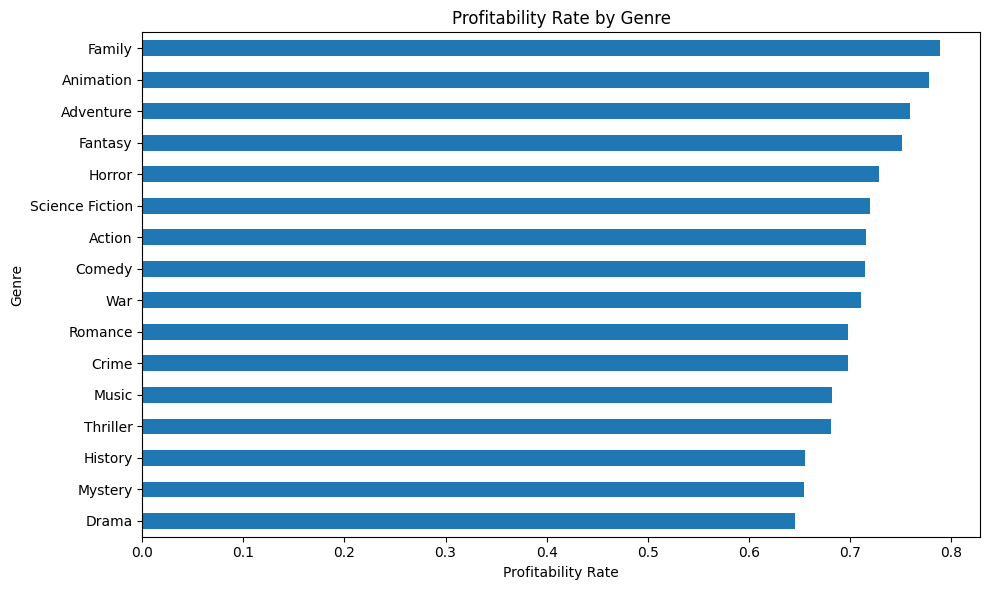

In [25]:
plt.figure(figsize=(10, 6))

genre_analysis["profitability_rate"].sort_values().plot(
    kind="barh"
)

plt.xlabel("Profitability Rate")
plt.ylabel("Genre")
plt.title("Profitability Rate by Genre")

plt.tight_layout()
plt.show()

In [27]:
genre_analysis.sort_values(
    "profitability_rate",
    ascending=False
).round(3)

,movies,profitability_rate,median_roi,median_revenue,average_rating
genre_list,,,,,
Family,532,0.789,1.484,94547600.5,6.187
Animation,293,0.778,1.775,117932401.0,6.477
Adventure,960,0.759,1.292,85370015.0,6.250
Fantasy,511,0.751,1.126,84552250.0,6.171
Horror,586,0.729,1.485,24023266.5,5.825
Science Fiction,635,0.720,1.002,50244700.0,6.102
Action,1415,0.717,1.014,54700105.0,6.104
Comedy,1852,0.715,1.107,32307307.0,6.090
War,204,0.711,1.029,25561499.5,6.714


In [26]:
genre_analysis.sort_values(
    "average_rating",
    ascending=False
)[["movies", "average_rating", "profitability_rate"]]

,movies,average_rating,profitability_rate
genre_list,,,
History,235,6.797447,0.655319
War,204,6.714216,0.710784
Drama,2587,6.516003,0.645922
Animation,293,6.477474,0.778157
Music,192,6.477083,0.682292
Crime,862,6.387355,0.698376
Mystery,443,6.342664,0.654628
Romance,1015,6.308670,0.698522
Adventure,960,6.249687,0.759375


In [28]:
financial["release_date"] = pd.to_datetime(
    financial["release_date"],
    errors="coerce"
)

financial["release_year"] = financial["release_date"].dt.year

financial["decade"] = (
    financial["release_year"] // 10 * 10
)

In [29]:
decade_analysis = (
    financial[financial["release_year"] >= 1960]
    .groupby("decade")
    .agg(
        movies=("title", "count"),
        profitability_rate=("profitable", "mean"),
        median_roi=("roi", "median"),
        average_rating=("vote_average", "mean")
    )
)

decade_analysis.round(3)

,movies,profitability_rate,median_roi,average_rating
decade,,,,
1960,130,0.846,2.789,6.945
1970,190,0.905,5.284,6.677
1980,520,0.712,1.463,6.311
1990,942,0.639,0.739,6.198
2000,1780,0.671,0.728,6.163
2010,1640,0.696,1.087,6.253


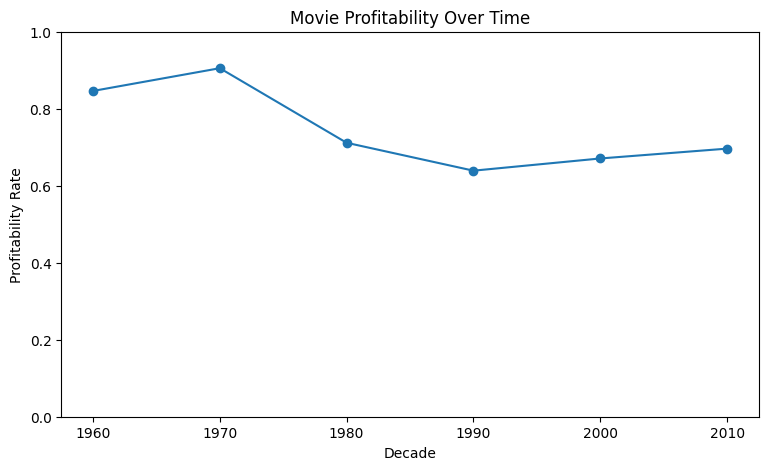

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(
    decade_analysis.index,
    decade_analysis["profitability_rate"],
    marker="o"
)

plt.xlabel("Decade")
plt.ylabel("Profitability Rate")
plt.title("Movie Profitability Over Time")
plt.ylim(0, 1)

plt.show()

In [31]:
financial["has_collection"] = (
    financial["belongs_to_collection"].notna()
).astype(int)

collection_analysis = financial.groupby(
    "has_collection"
).agg(
    movies=("title", "count"),
    profitability_rate=("profitable", "mean"),
    median_budget=("budget", "median"),
    median_revenue=("revenue", "median"),
    median_roi=("roi", "median"),
    average_rating=("vote_average", "mean")
)

collection_analysis.index = [
    "Standalone",
    "Franchise / Collection"
]

collection_analysis.round(3)

,movies,profitability_rate,median_budget,median_revenue,median_roi,average_rating
Standalone,4157,0.638,15000000.0,21001563.0,0.616,6.294
Franchise / Collection,1224,0.903,24500000.0,93310769.5,2.715,6.200


In [35]:
genre_df = financial.explode("genre_list")

In [36]:
genre_collection = (
    genre_df.groupby(["genre_list", "has_collection"])
    .agg(
        movies=("title", "count"),
        profitability_rate=("profitable", "mean"),
        median_roi=("roi", "median"),
        average_rating=("vote_average", "mean")
    )
    .reset_index()
)

genre_collection[
    genre_collection["movies"] >= 50
].sort_values(
    "profitability_rate",
    ascending=False
).head(15).round(3)

,genre_list,has_collection,movies,profitability_rate,median_roi,average_rating
15,Family,1,206,0.951,3.206,6.264
3,Adventure,1,398,0.940,2.945,6.324
7,Comedy,1,410,0.922,2.986,6.035
5,Animation,1,119,0.916,3.276,6.508
1,Action,1,495,0.909,2.487,6.251
23,Horror,1,255,0.898,2.712,5.878
17,Fantasy,1,194,0.892,2.453,6.106
29,Romance,1,88,0.886,4.125,6.177
34,Thriller,1,408,0.885,2.382,6.114
9,Crime,1,190,0.884,2.507,6.372


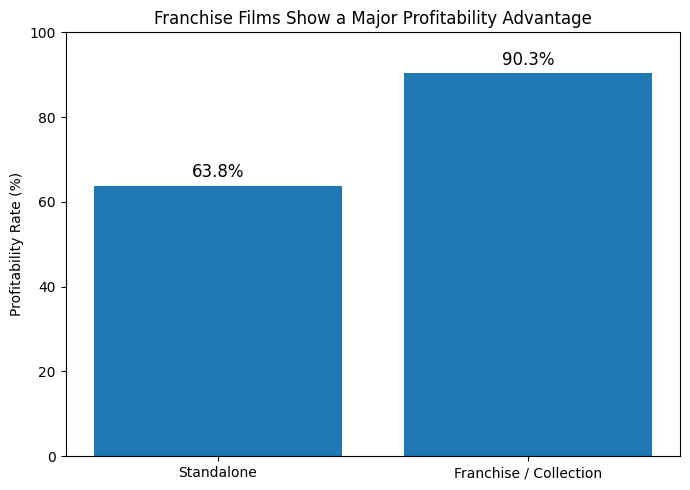

In [37]:
plt.figure(figsize=(7, 5))

labels = ["Standalone", "Franchise / Collection"]
rates = [63.8, 90.3]

bars = plt.bar(labels, rates)

plt.ylabel("Profitability Rate (%)")
plt.title("Franchise Films Show a Major Profitability Advantage")
plt.ylim(0, 100)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        f"{rate}%",
        ha="center",
        fontsize=12
    )

plt.tight_layout()
plt.show()